In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [2]:
data = np.loadtxt("OneDrive\\Desktop\\CS465\\LABS\\Lab2\\Lab2Data.txt", delimiter=",")
x, y = data[:, :2], data[:, 2]
m = len(y)


In [3]:
X = np.hstack((np.ones((m, 1)), x))
print(X)

[[ 1.         34.62365962 78.02469282]
 [ 1.         30.28671077 43.89499752]
 [ 1.         35.84740877 72.90219803]
 [ 1.         60.18259939 86.3085521 ]
 [ 1.         79.03273605 75.34437644]
 [ 1.         45.08327748 56.31637178]
 [ 1.         61.10666454 96.51142588]
 [ 1.         75.02474557 46.55401354]
 [ 1.         76.0987867  87.42056972]
 [ 1.         84.43281996 43.53339331]
 [ 1.         95.86155507 38.22527806]
 [ 1.         75.01365839 30.60326323]
 [ 1.         82.30705337 76.4819633 ]
 [ 1.         69.36458876 97.71869196]
 [ 1.         39.53833914 76.03681085]
 [ 1.         53.97105215 89.20735014]
 [ 1.         69.07014406 52.74046973]
 [ 1.         67.94685548 46.67857411]
 [ 1.         70.66150955 92.92713789]
 [ 1.         76.97878373 47.57596365]
 [ 1.         67.37202755 42.83843832]
 [ 1.         89.67677575 65.79936593]
 [ 1.         50.53478829 48.85581153]
 [ 1.         34.21206098 44.2095286 ]
 [ 1.         77.92409145 68.97235999]
 [ 1.         62.27101367

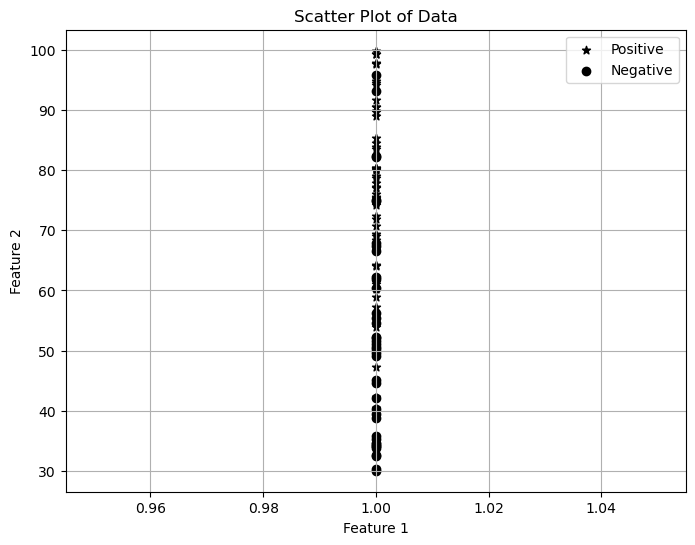

In [7]:
def plotData(X, y):
    # Separate the data points based on the labels in y
    positive = (y == 1)
    negative = (y == 0)
    
    # Plot the data points with different markers for positive and negative classes
    plt.figure(figsize=(8, 6))
    plt.scatter(X[positive, 0], X[positive, 1], c='k', marker='*', label='Positive')
    plt.scatter(X[negative, 0], X[negative, 1], c='k', marker='o', label='Negative')
    
    # Add labels, title, and legend
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter Plot of Data')
    plt.legend()
    plt.grid(True)
    plt.show()
plotData(X, y)


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) 
def costFunction(theta, X, y):
    h = sigmoid(X @ theta)
    # Compute the cost function vectorized (do not understand the formula, in this slides its diffrent)
    cost = (-1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    return cost
def gradient(theta,X,y):
    h = sigmoid(X @ theta)
    # Compute the gradient (vectorized) (same as the one above )
    grad = (1/m) * X.T @ (h - y)
    return grad
def optimizeTheta(X, y, initial_theta):
     result = opt.minimize(fun=costFunction, x0=initial_theta, args=(X, y), method='TNC', jac=gradient)
     return result
theta_init = np.zeros(X.shape[1])

# Perform optimization to find optimal theta
result = optimizeTheta(X, y, theta_init)

# Extract optimal theta and corresponding cost
optimal_theta = result.x
minimized_cost = result.fun
print(f"Optimal theta: {optimal_theta}")
print(f"Minimized cost: {minimized_cost}")

Optimal theta: [-25.16131874   0.20623159   0.20147149]
Minimized cost: 0.20349770158947414


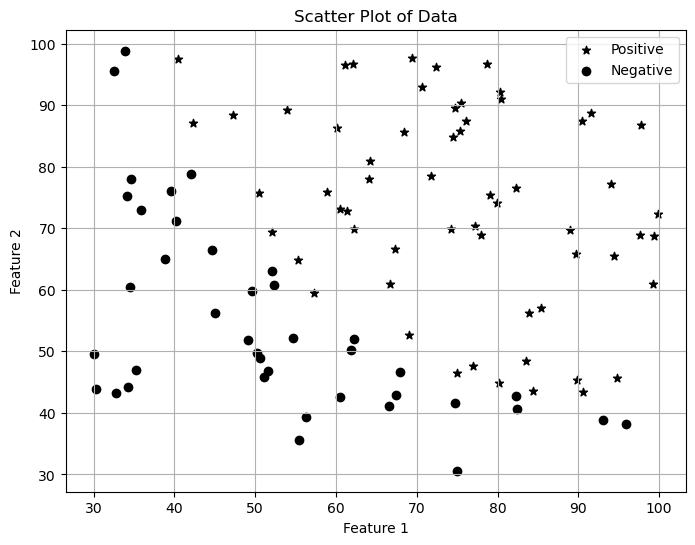

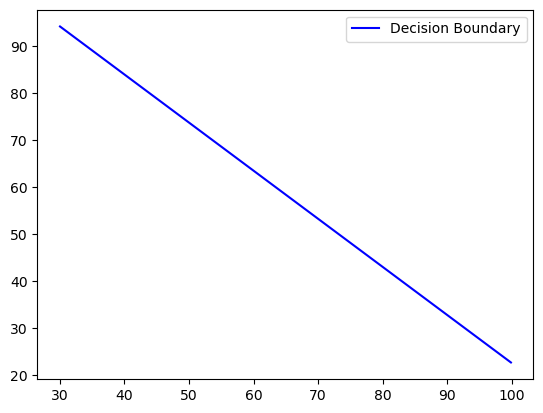

In [9]:
def plotDecisionBoundary(theta, X, y):
    """
    Plot the decision boundary for logistic regression along with the data points.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1), including the bias term.
        y (numpy.ndarray): The target vector with shape (m,).
    """
    # Plot the data points
    plotData(X[:, 1:], y)  # Exclude the bias term for scatter plot
    
    # Only works for 2D data (n=2 including bias)
    if X.shape[1] == 3:
        # Define the range of x values (feature 1)
        x_vals = np.array([np.min(X[:, 1]), np.max(X[:, 1])])
        
        # Compute the corresponding y values using theta
        # theta0 + theta1 * x1 + theta2 * x2 = 0 -> x2 = -(theta0 + theta1 * x1) / theta2
        y_vals = -(theta[0] + theta[1] * x_vals) / theta[2]
        
        # Plot the decision boundary
        plt.plot(x_vals, y_vals, 'b-', label='Decision Boundary')
    
    # Add legend
    plt.legend()
    plt.show()
plotDecisionBoundary(optimal_theta, X, y)

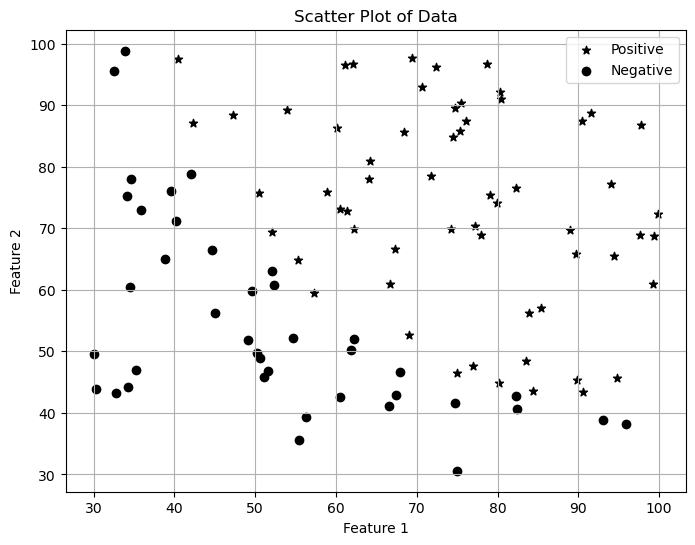

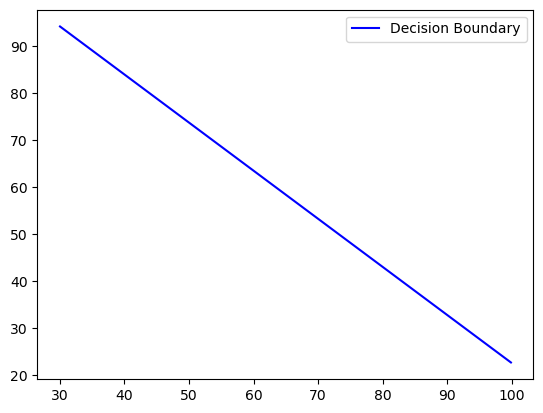

Training Accuracy: 89.00%


In [10]:
def predict(theta, X):
    """
    Make predictions using logistic regression parameters.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1), including the bias term.
    
    Returns:
        numpy.ndarray: Predictions (0 or 1) for each example.
    """
    # Compute the probability using the sigmoid function
    probabilities = sigmoid(X @ theta)
    
    # Apply threshold at 0.5 to make predictions
    return (probabilities >= 0.5).astype(int)

def computeAccuracy(theta, X, y):
    """
    Compute the accuracy of the logistic regression model.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1), including the bias term.
        y (numpy.ndarray): The target vector with shape (m,).
    
    Returns:
        float: The accuracy as a percentage.
    """
    # Make predictions
    predictions = predict(theta, X)
    
    # Compute accuracy
    accuracy = np.mean(predictions == y) * 100
    return accuracy

# Example usage
# Plot the decision boundary
plotDecisionBoundary(optimal_theta, X, y)

# Compute and display accuracy
accuracy = computeAccuracy(optimal_theta, X, y)
print(f"Training Accuracy: {accuracy:.2f}%")

In [24]:
def mapFeature(x1, x2, degree=6):
    """
    Maps two input features (x1, x2) to polynomial features up to a given degree.
    
    Parameters:
        x1 (numpy.ndarray): Feature 1 (m,).
        x2 (numpy.ndarray): Feature 2 (m,).
        degree (int): The degree of polynomial features to generate.
    
    Returns:
        numpy.ndarray: A feature matrix with polynomial features (m, n).
    """
    m = x1.shape[0]
    out = np.ones((m, 1))  # Start with a column of ones (bias term)
    
    for i in range(1, degree + 1):
        for j in range(i + 1):
            term = (x1 ** (i - j)) * (x2 ** j)
            out = np.hstack((out, term.reshape(-1, 1)))
    
    return out

    
x1 = X[:, 1]  # Second column (first feature)
x2 = X[:, 2]  # Third column (second feature)
degree=6      # Degree to predict to
mapFeature(x1,x2,degree)

def costFunctionReg(theta, X, y, lambda_):
    """
    Compute the regularized cost function for logistic regression.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1).
        y (numpy.ndarray): The target vector with shape (m,).
        lambda_ (float): The regularization parameter.
    
    Returns:
        float: The regularized cost.
    """
    m = y.size
    h = sigmoid(X @ theta)
    
    # Clip h to avoid log(0)
    epsilon = 1e-10  # Small value to avoid log(0)
    h = np.clip(h, epsilon, 1 - epsilon)
    
    # Compute regularized cost
    cost = (-1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    reg = (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)  # Exclude theta[0] from regularization
    
    return cost + reg


def gradientReg(theta, X, y, lambda_):
    """
    Compute the gradient of the regularized cost function.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1).
        y (numpy.ndarray): The target vector with shape (m,).
        lambda_ (float): The regularization parameter.
    
    Returns:
        numpy.ndarray: The gradient vector of shape (n+1,).
    """
    h = sigmoid(X @ theta)
    
    # Compute the gradient
    grad = (1/m) * (X.T @ (h - y))
    grad[1:] += (lambda_ / m) * theta[1:]  # Regularize all except theta[0]. from regularization, this is the regularized function diffrence 
    return grad


λ = 1: Training Accuracy = 60.00%


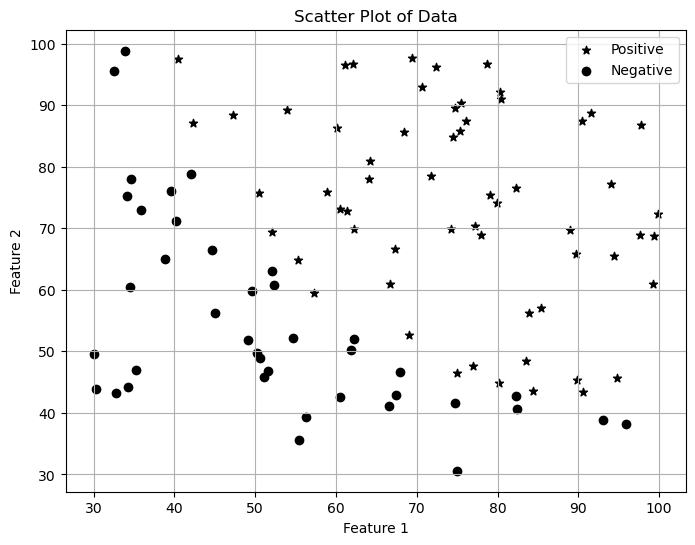

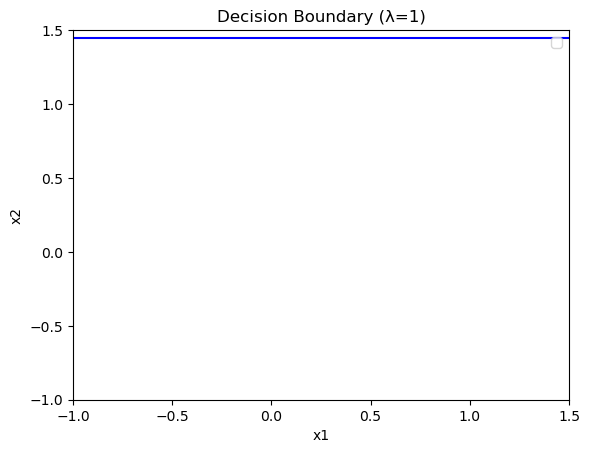

In [28]:
def plotDecisionBoundaryReg(theta, X, y, lambda_, degree=6):
    """
    Plot the decision boundary for regularized logistic regression along with the data points.
    """
    # Plot the data points
    plotData(X[:, 1:3], y)  # Exclude polynomial features for scatter plot visualization

    # Create a grid of values
    u = np.linspace(-1, 1.5, 50)
    v = np.linspace(-1, 1.5, 50)
    z = np.zeros((len(u), len(v)))

    # Evaluate z = theta * features for the grid
    for i in range(len(u)):
        for j in range(len(v)):
            # Map the features for the grid points (u[i], v[j])
            mapped_features = mapFeature(np.array([u[i]]), np.array([v[j]]), degree)
            z[i, j] = mapped_features.dot(theta)

    # Plot contour where z = 0 (decision boundary)
    plt.contour(u, v, z.T, levels=[0], colors='b')
    plt.title(f'Decision Boundary (λ={lambda_})')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(['y = 1', 'y = 0', 'Decision Boundary'])
    plt.show()


def evaluateModel(X, y, lambda_):
    """
    Evaluate logistic regression with regularization for a given λ.
    
    Parameters:
        X (numpy.ndarray): The feature matrix with shape (m, n+1).
        y (numpy.ndarray): The target vector with shape (m,).
        lambda_ (float): The regularization parameter.
    
    Returns:
        float: The training accuracy.
    """
    # Initialize theta
    initial_theta = np.zeros(X.shape[1])
    
    # Optimize theta
    result = opt.minimize(fun=costFunctionReg, x0=initial_theta, args=(X, y, lambda_), method='TNC', jac=gradientReg)
    optimal_theta = result.x
    
    # Compute accuracy
    accuracy = computeAccuracy(optimal_theta, X, y)
    return optimal_theta, accuracy


# Map features for training data (X)
X_mapped = mapFeature(X[:, 1], X[:, 2], degree=6)

# Initialize theta for the regularized logistic regression
initial_theta = np.zeros(X_mapped.shape[1])

def plotDecisionBoundaryReg(theta, X, y, lambda_, degree=6):
    """
    Plot the decision boundary for regularized logistic regression along with the data points.
    
    Parameters:
        theta (numpy.ndarray): The parameters (weights) for the logistic regression model.
        X (numpy.ndarray): The feature matrix with shape (m, n+1).
        y (numpy.ndarray): The target vector with shape (m,).
        lambda_ (float): The regularization parameter.
        degree (int): The polynomial degree used in feature mapping.
    """
    # Plot the data points
    plotData(X[:, 1:3], y)  # Exclude polynomial features for scatter plot visualization
    
    # Create a grid of values
    u = np.linspace(-1, 1.5, 50)
    v = np.linspace(-1, 1.5, 50)
    z = np.zeros((len(u), len(v)))

    # Evaluate z = theta * features for the grid
    for i in range(len(u)):
        for j in range(len(v)):
            # Map the features for the grid points (u[i], v[j])
            mapped_features = mapFeature(np.array([u[i]]), np.array([v[j]]), degree)
        
        # Ensure the result is a scalar
        z[i, j] = mapped_features.dot(theta).item()

    
    # Plot contour where z = 0 (decision boundary)
    plt.contour(u, v, z.T, levels=[0], colors='b')
    plt.title(f'Decision Boundary (λ={lambda_})')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(['y = 1', 'y = 0', 'Decision Boundary'])
    plt.show()

lambda_ = 1  # Choose a lambda value
optimal_theta, accuracy = evaluateModel(X_mapped, y, lambda_)
print(f"λ = {lambda_}: Training Accuracy = {accuracy:.2f}%")
plotDecisionBoundaryReg(optimal_theta, X, y, lambda_)
